In [156]:
import pandas as pd
from sqlalchemy import create_engine
import urllib
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [157]:
server = 'LAPTOP-4Q1EDIFO' 
database = 'banking_case'
params = urllib.parse.quote_plus(
    f'DRIVER={{SQL Server}};'
    f'SERVER={server};'
    f'DATABASE={database};'
    f'Trusted_Connection=yes;'
)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

Data Loading

In [158]:
query = "SELECT * FROM [NewYork_Airbnb].[dbo].[newyork]"
df = pd.read_sql(query, engine)

c:\Users\chandra\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1050.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [159]:
engine.dispose()
print("Connection Closed")

Connection Closed


In [160]:
df.head()
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
20765,2.473690e+07,Rental unit in New York · ★4.75 · 1 bedroom · ...,186680487,Henry D,Manhattan,Lower East Side,40.711380,-73.991562,Private room,45.0,...,2023-09-29,1.81,1.0,157.0,12.0,No License,4.75,1,1,1
20766,2.835711e+06,Rental unit in New York · ★4.46 · 1 bedroom · ...,3237504,Aspen,Manhattan,Greenwich Village,40.730579,-74.000702,Entire home/apt,105.0,...,2023-07-01,0.48,1.0,0.0,1.0,No License,4.46,1,2,1
20767,5.182527e+07,Rental unit in New York · ★4.93 · 1 bedroom · ...,304317395,Jeff,Manhattan,Hell's Kitchen,40.757351,-73.993431,Entire home/apt,299.0,...,2023-12-08,2.09,1.0,0.0,27.0,No License,4.93,1,1,1
20768,7.830000e+17,Rental unit in New York · ★5.0 · 1 bedroom · 1...,163083101,Marissa,Manhattan,Chinatown,40.713749,-73.991470,Entire home/apt,115.0,...,2023-09-17,0.91,1.0,363.0,7.0,No License,5,1,1,1
20769,5.660000e+17,Rental unit in Queens · ★4.89 · 1 bedroom · 1 ...,93827372,Glenroy,Queens,Rosedale,40.658875,-73.728653,Private room,102.0,...,2023-12-10,4.50,1.0,0.0,62.0,OSE-STRREG-0000513,4.89,1,1,1


In [161]:
df.shape

(20770, 22)

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20770 entries, 0 to 20769
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20770 non-null  float64
 1   name                            20770 non-null  object 
 2   host_id                         20770 non-null  int64  
 3   host_name                       20770 non-null  object 
 4   neighbourhood_group             20770 non-null  object 
 5   neighbourhood                   20763 non-null  object 
 6   latitude                        20763 non-null  float64
 7   longitude                       20763 non-null  float64
 8   room_type                       20763 non-null  object 
 9   price                           20736 non-null  float64
 10  minimum_nights                  20763 non-null  float64
 11  number_of_reviews               20763 non-null  float64
 12  last_review                     

In [163]:
#Generate descriptive statistics
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.077000e+04,2.077000e+04,20763.000000,20763.000000,20736.000000,20763.000000,20763.000000,20763.000000,20763.000000,20763.000000,20763.000000
mean,3.033858e+17,1.749049e+08,40.726821,-73.939179,187.714940,28.558493,42.610605,1.257589,18.866686,206.067957,10.848962
std,3.901221e+17,1.725657e+08,0.060293,0.061403,1023.245124,33.532697,73.523401,1.904472,70.921443,135.077259,21.354876
min,2.595000e+03,1.678000e+03,40.500313,-74.249840,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000000
25%,2.707260e+07,2.041184e+07,40.684158,-73.980755,80.000000,30.000000,4.000000,0.210000,1.000000,87.000000,1.000000
50%,4.992852e+07,1.086990e+08,40.722889,-73.949600,125.000000,30.000000,14.000000,0.650000,2.000000,215.000000,3.000000
75%,7.220000e+17,3.143997e+08,40.763107,-73.917477,199.000000,30.000000,49.000000,1.800000,5.000000,353.000000,15.000000
max,1.050000e+18,5.504035e+08,40.911148,-73.713654,100000.000000,1250.000000,1865.000000,75.489998,713.000000,365.000000,1075.000000


DataCleaning

In [164]:
df.isnull().sum()


id                                 0
name                               0
host_id                            0
host_name                          0
neighbourhood_group                0
neighbourhood                      7
latitude                           7
longitude                          7
room_type                          7
price                             34
minimum_nights                     7
number_of_reviews                  7
last_review                        7
reviews_per_month                  7
calculated_host_listings_count     7
availability_365                   7
number_of_reviews_ltm              7
license                            0
rating                             0
bedrooms                           0
beds                               0
baths                              0
dtype: int64

In [165]:
df.isnull().sum()

id                                 0
name                               0
host_id                            0
host_name                          0
neighbourhood_group                0
neighbourhood                      7
latitude                           7
longitude                          7
room_type                          7
price                             34
minimum_nights                     7
number_of_reviews                  7
last_review                        7
reviews_per_month                  7
calculated_host_listings_count     7
availability_365                   7
number_of_reviews_ltm              7
license                            0
rating                             0
bedrooms                           0
beds                               0
baths                              0
dtype: int64

In [166]:
#Droping null values
df.dropna(inplace=True)
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
license                           0
rating                            0
bedrooms                          0
beds                              0
baths                             0
dtype: int64

In [167]:
df.duplicated().sum()
df[df.duplicated()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
6,4.527754e+07,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766609,-73.988098,Entire home/apt,144.0,...,2023-05-01,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
7,9.710000e+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750763,-73.994606,Entire home/apt,187.0,...,2023-12-18,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
8,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835602,-73.942497,Private room,120.0,...,2023-09-17,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
9,4.089661e+07,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751122,-73.978600,Entire home/apt,85.0,...,2023-12-03,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1
10,4.958498e+07,Rental unit in New York · ★5.0 · 1 bedroom · 1...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.759949,-73.992958,Entire home/apt,115.0,...,2023-07-29,0.16,139.0,276.0,2.0,No License,5,1,1,1
20736,7.990000e+17,Rental unit in New York · 2 bedrooms · 2 beds ...,224733902,CozySuites Copake,Manhattan,Upper East Side,40.768970,-73.957596,Entire home/apt,153.0,...,2023-09-15,0.41,8.0,308.0,2.0,No License,No rating,2,2,2
20737,5.930000e+17,Rental unit in New York · ★4.79 · 2 bedrooms ·...,23219783,Rob,Manhattan,West Village,40.730221,-74.002907,Entire home/apt,175.0,...,2023-11-22,2.03,4.0,129.0,25.0,No License,4.79,2,2,1
20738,9.230000e+17,Loft in New York · ★4.33 · 1 bedroom · 2 beds ...,520265731,Rodrigo,Manhattan,Greenwich Village,40.728390,-73.999542,Entire home/apt,156.0,...,2024-01-02,2.60,1.0,356.0,9.0,Exempt,4.33,1,2,1
20739,1.336161e+07,Rental unit in New York · ★4.89 · 2 bedrooms ·...,8961407,Jamie,Manhattan,Harlem,40.805698,-73.946251,Entire home/apt,397.0,...,2023-09-08,1.08,3.0,274.0,3.0,No License,4.89,2,2,1
20740,5.119566e+07,Rental unit in New York · Studio · 1 bed · 1 bath,51501835,Jeniffer,Manhattan,Chinatown,40.718361,-73.995850,Entire home/apt,100.0,...,2023-05-25,0.08,139.0,306.0,1.0,No License,No rating,Studio,1,1


In [168]:
#Removing Duplicated
df.drop_duplicates(inplace=True)

In [169]:
# type casting 
# changing data types 

df.dtypes

df['id'] = df['id'].astype(object)
df.dtypes

df['host_id'] = df['host_id'].astype(object)
df.dtypes

id                                 object
name                               object
host_id                            object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                            object
rating                             object
bedrooms                           object
beds                               object
baths                              object
dtype: object

Data Analysis

<Axes: xlabel='price'>

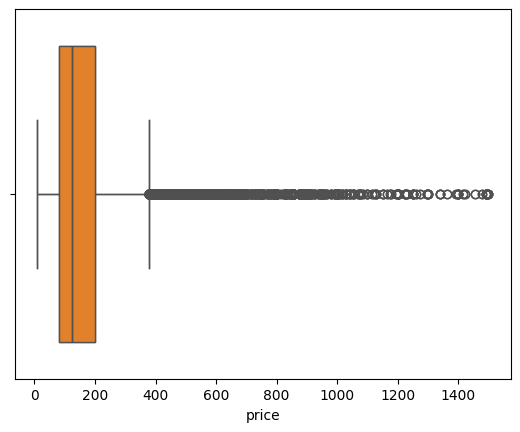

In [170]:
#Identifing Outliers
df_1= df[df['price'] < 1500]

sns.boxplot(data=df_1, x='price')
sns.boxplot(data=df_1,x='price')

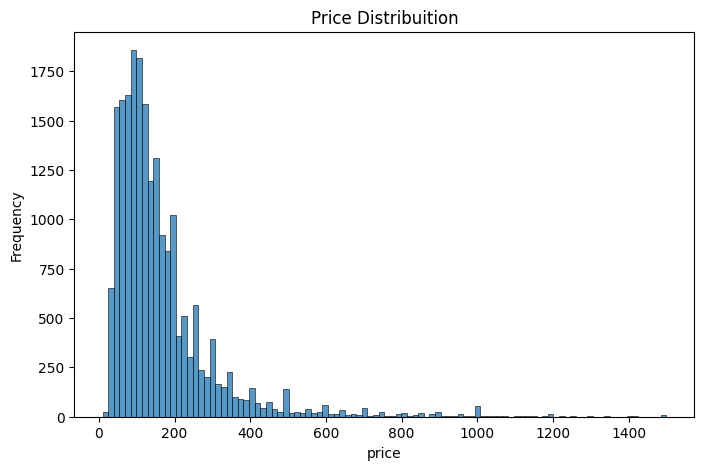

In [171]:
#Price distribuion

plt.figure(figsize=(8, 5))
sns.histplot(data=df_1, x='price', bins=100)
plt.title('Price Distribuition')
plt.ylabel("Frequency")
plt.show()

In [172]:
df_1.dtypes

id                                 object
name                               object
host_id                            object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                            object
rating                             object
bedrooms                           object
beds                               object
baths                              object
dtype: object

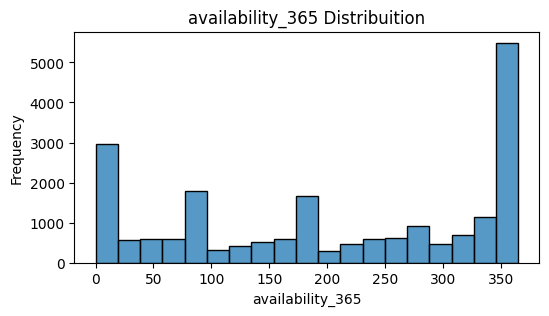

In [173]:
#Price distribuion
plt.figure(figsize=(6, 3))
sns.histplot(data=df_1, x='availability_365')
plt.title('availability_365 Distribuition')
plt.ylabel("Frequency")
plt.show()

In [174]:
df.dtypes

id                                 object
name                               object
host_id                            object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                            object
rating                             object
bedrooms                           object
beds                               object
baths                              object
dtype: object

In [175]:
df_1.groupby(by='neighbourhood_group')['price'].mean()

neighbourhood_group
Bronx            107.990506
Brooklyn         155.138317
Manhattan        204.146014
Queens           121.681939
Staten Island    118.780069
Name: price, dtype: float64

Feature Engineering


In [176]:

df_1['price'] = pd.to_numeric(df_1['price'], errors='coerce')
df_1['beds'] = pd.to_numeric(df_1['beds'], errors='coerce')

df_1['price per bed'] = df_1['price'] / df_1['beds']
# average price per bed
df_1.groupby(by='neighbourhood_group')['price per bed'].mean()

C:\Users\chandra\AppData\Local\Temp\ipykernel_15688\2640378989.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1['price'] = pd.to_numeric(df_1['price'], errors='coerce')
C:\Users\chandra\AppData\Local\Temp\ipykernel_15688\2640378989.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1['beds'] = pd.to_numeric(df_1['beds'], errors='coerce')
C:\Users\chandra\AppData\Local\Temp\ipykernel_15688\2640378989.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

neighbourhood_group
Bronx             74.713639
Brooklyn          99.788493
Manhattan        138.708057
Queens            76.336210
Staten Island     67.728101
Name: price per bed, dtype: float64

In [177]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228.0,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683708,-73.964607,Private room,55.0,...,2015-12-20,0.03,1.0,0.0,0.0,No License,5,1,1,Not specified
1,45277536.0,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766609,-73.988098,Entire home/apt,144.0,...,2023-05-01,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
2,971000021526773760.0,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750763,-73.994606,Entire home/apt,187.0,...,2023-12-18,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
3,3857863.0,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835602,-73.942497,Private room,120.0,...,2023-09-17,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
4,40896612.0,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751122,-73.978600,Entire home/apt,85.0,...,2023-12-03,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1


In [178]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'rating',
       'bedrooms', 'beds', 'baths'],
      dtype='object')

<Axes: xlabel='neighbourhood_group', ylabel='price'>

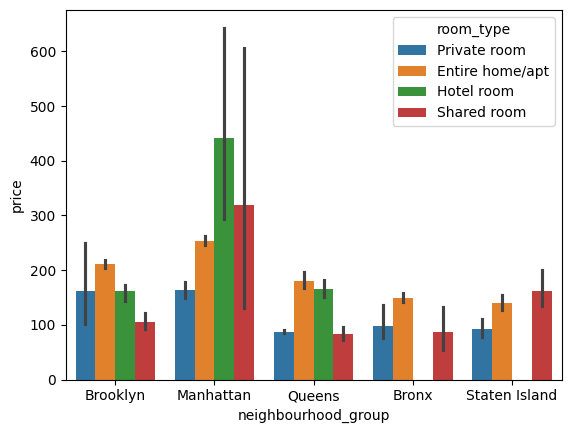

In [179]:
# price dependency on neighbourhood
sns.barplot(data=df, x='neighbourhood_group', y='price', hue='room_type')

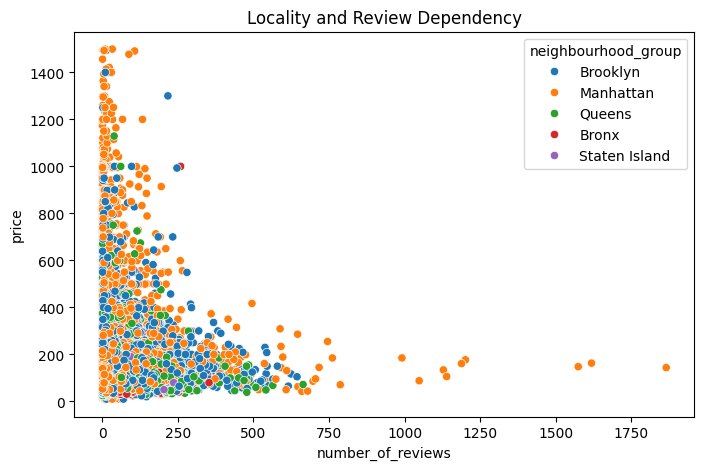

In [180]:
# number of reviews and price rel
plt.figure(figsize=(8, 5))
plt.title("Locality and Review Dependency")
sns.scatterplot(data=df_1, x='number_of_reviews', y='price', hue='neighbourhood_group')
plt.show()

In [181]:
df.dtypes

id                                 object
name                               object
host_id                            object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                            object
rating                             object
bedrooms                           object
beds                               object
baths                              object
dtype: object

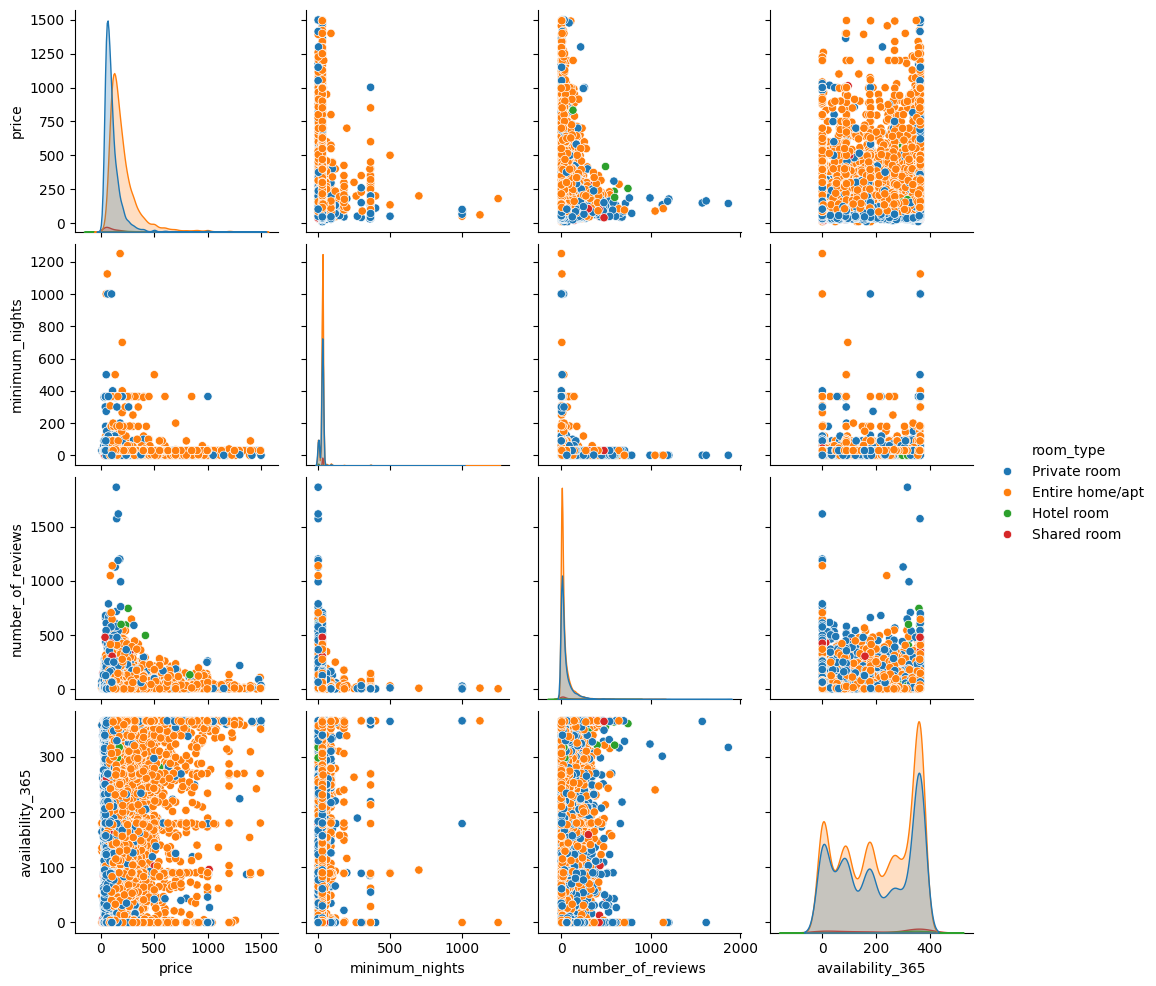

In [182]:
sns.pairplot(data=df_1, vars=['price', 'minimum_nights', 'number_of_reviews', 'availability_365'], hue='room_type')

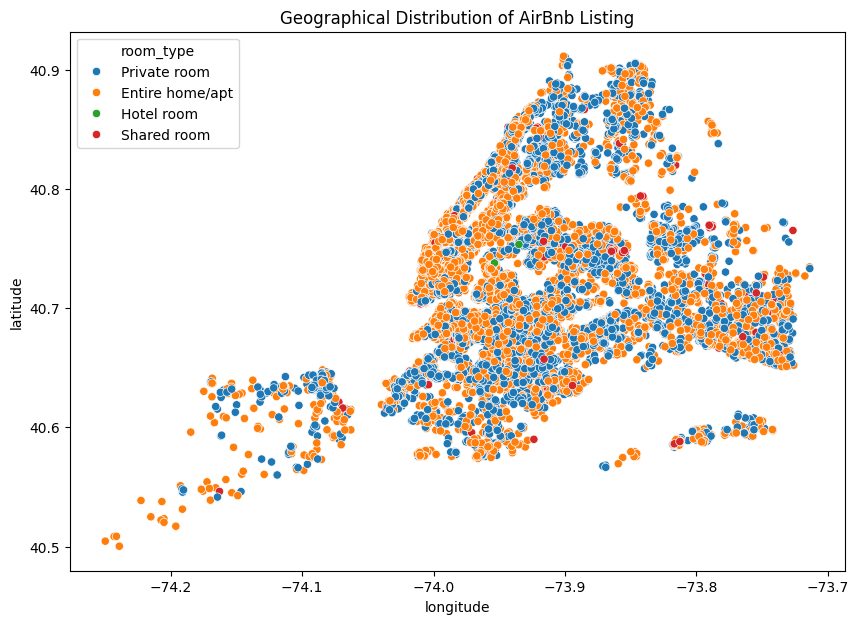

In [183]:
#Geographical Distribution of AirBnb Listing
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_1, x='longitude', y='latitude', hue='room_type')
plt.title("Geographical Distribution of AirBnb Listing")
plt.show()

<Axes: >

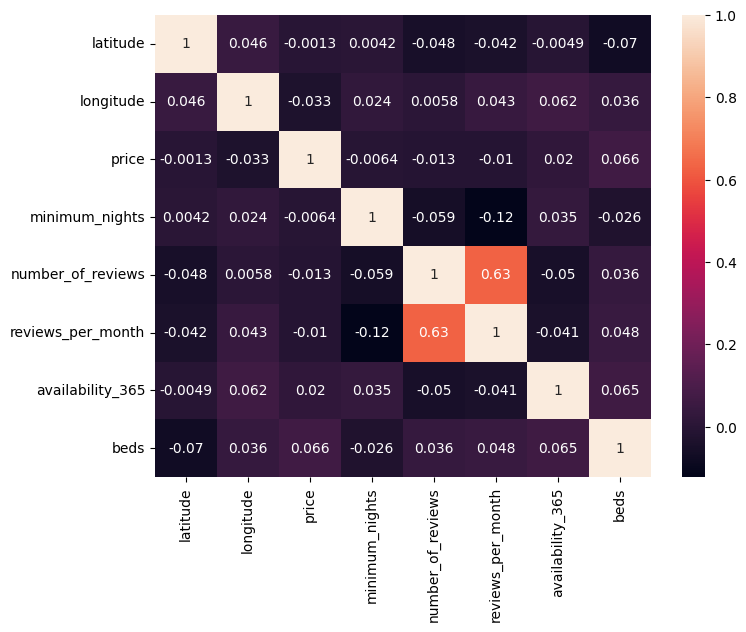

In [184]:
# heat map - correlation of one variable with others for numerical column

corr = df[['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'beds']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(data=corr, annot=True)